# Customer Churn Prediction

## Problem Statement

Customer churn is a major problem in the telecommunications industry.
The goal of this project is to build a machine learning model that can
predict whether a customer is likely to leave the company.

By identifying high-risk customers early, businesses can take proactive
steps such as retention campaigns, personalized offers, and customer
support improvements.

## Objectives

- Perform exploratory data analysis (EDA)
- Clean and preprocess the data
- Engineer meaningful features
- Train multiple machine learning models
- Tune hyperparameters
- Compare model performance
- Select the best model
- Provide business recommendations

# Step 1: Understand the Dataset and Load the Data

## Import Libraries

In [1]:
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# Models
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

from sklearn.model_selection import GridSearchCV

## Load the Dataset

In [2]:
train_df = pd.read_csv("Training_data.csv")
test_df = pd.read_csv("Testing_data.csv")

## View First 5 rows

In [3]:
train_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.40,No
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790.00,No
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,NaN,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.60,No


In [4]:
test_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,6080-TCMYC,Male,0,Yes,Yes,40,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,81.20,3292.30,No
1,7285-KLOTR,Female,0,Yes,No,12,Yes,Yes,DSL,Yes,...,Yes,No,Yes,Yes,One year,No,Electronic check,78.85,876.75,No
2,7486-KSRVI,Male,0,No,No,43,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,One year,Yes,Electronic check,100.00,4211.55,Yes
3,9924-JPRMC,Male,0,No,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,118.20,8547.15,No
4,4439-YRNVD,Female,0,No,No,10,No,No phone service,DSL,No,...,No,Yes,No,No,Month-to-month,No,Electronic check,36.25,374.00,No


## Check Dataset Shape

In [5]:
train_df.shape

(5634, 21)

In [6]:
test_df.shape

(1409, 21)

## Check Column Names

In [7]:
train_df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

## Check Data Types

In [8]:
train_df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


## Basic Statistical Summary

In [9]:
train_df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,5634.000000,5634.000000,5240.000000,5344.000000
mean,0.159744,32.606851,65.102052,2283.932279
std,0.366401,24.614976,30.056443,2266.719324
min,0.000000,0.000000,18.250000,18.850000
25%,0.000000,9.000000,36.800000,406.612500
50%,0.000000,29.000000,70.650000,1396.450000
75%,0.000000,56.000000,90.050000,3778.362500
max,1.000000,72.000000,118.750000,8684.800000


For Categorical columns

In [10]:
train_df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,5634,5465,5634,5634,5634,5634,5634,5465,5634,5634,5634,5634,5634,5634,5634,5634,5634
unique,5634,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,3402-XRIUO,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,2744,2890,3960,5081,2701,2486,2720,2459,2485,2782,2244,2232,3094,3350,1892,4130


# Step 2: Exploratory Data Analysis (EDA)

In this section, we analyze the dataset to understand:

- Feature distributions
- Missing values
- Outliers
- Relationships between features
- Correlation with customer churn

## Check Missing Values

In [11]:
train_df.isnull().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


In [12]:
test_df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [13]:
missing_percentage = (train_df.isnull().sum()/len(train_df))*100

missing_percentage.sort_values(ascending = False)

,0
MonthlyCharges,6.993255
TotalCharges,5.147320
OnlineSecurity,2.999645
gender,2.999645
customerID,0.000000
Dependents,0.000000
Partner,0.000000
SeniorCitizen,0.000000
tenure,0.000000
InternetService,0.000000


In [14]:
test_missing_percentage = (
    test_df.isnull().sum()/len(test_df)
)*100

test_missing_percentage.sort_values(ascending=False)

,0
TotalCharges,0.141945
gender,0.000000
SeniorCitizen,0.000000
Partner,0.000000
customerID,0.000000
Dependents,0.000000
tenure,0.000000
MultipleLines,0.000000
PhoneService,0.000000
OnlineSecurity,0.000000


## Check Blank Spaces in TotalCharges

In [15]:
(train_df['TotalCharges'] == '').sum()

np.int64(0)

In [16]:
train_df['TotalCharges'] = pd.to_numeric(
    train_df['TotalCharges'],
    errors='coerce'
)

In [17]:
test_df['TotalCharges'] = pd.to_numeric(
    test_df['TotalCharges'],
    errors='coerce'
)

In [18]:
train_df['TotalCharges'].dtype

dtype('float64')

## Separate Numerical and Categorical Columns

In [19]:
numerical_cols = train_df.select_dtypes(
    include=['int64','float64']
).columns

categorical_cols = train_df.select_dtypes(
    include=['object']
).columns

In [20]:
print('Numerical Columns:')
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

Categorical Columns:
Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')


## Target Variable Distribution

In [21]:
# Check class distribution:
train_df['Churn'].value_counts()

,count
Churn,
No,4130
Yes,1504


In [22]:
# Percentage:
train_df['Churn'].value_counts(normalize=True)*100

,proportion
Churn,
No,73.304934
Yes,26.695066


## Visualize Churn Distribution

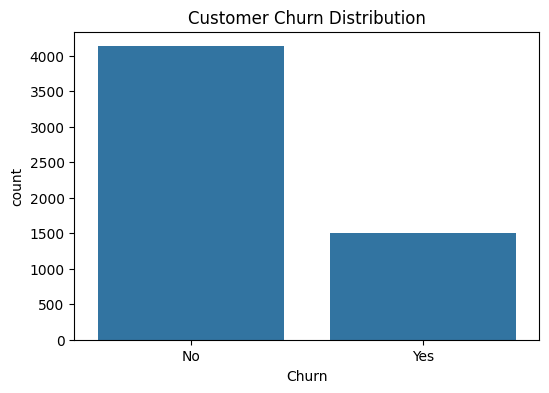

In [23]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Churn',
    data=train_df
)

plt.title("Customer Churn Distribution")
plt.show()

## Numerical Feature Distribution

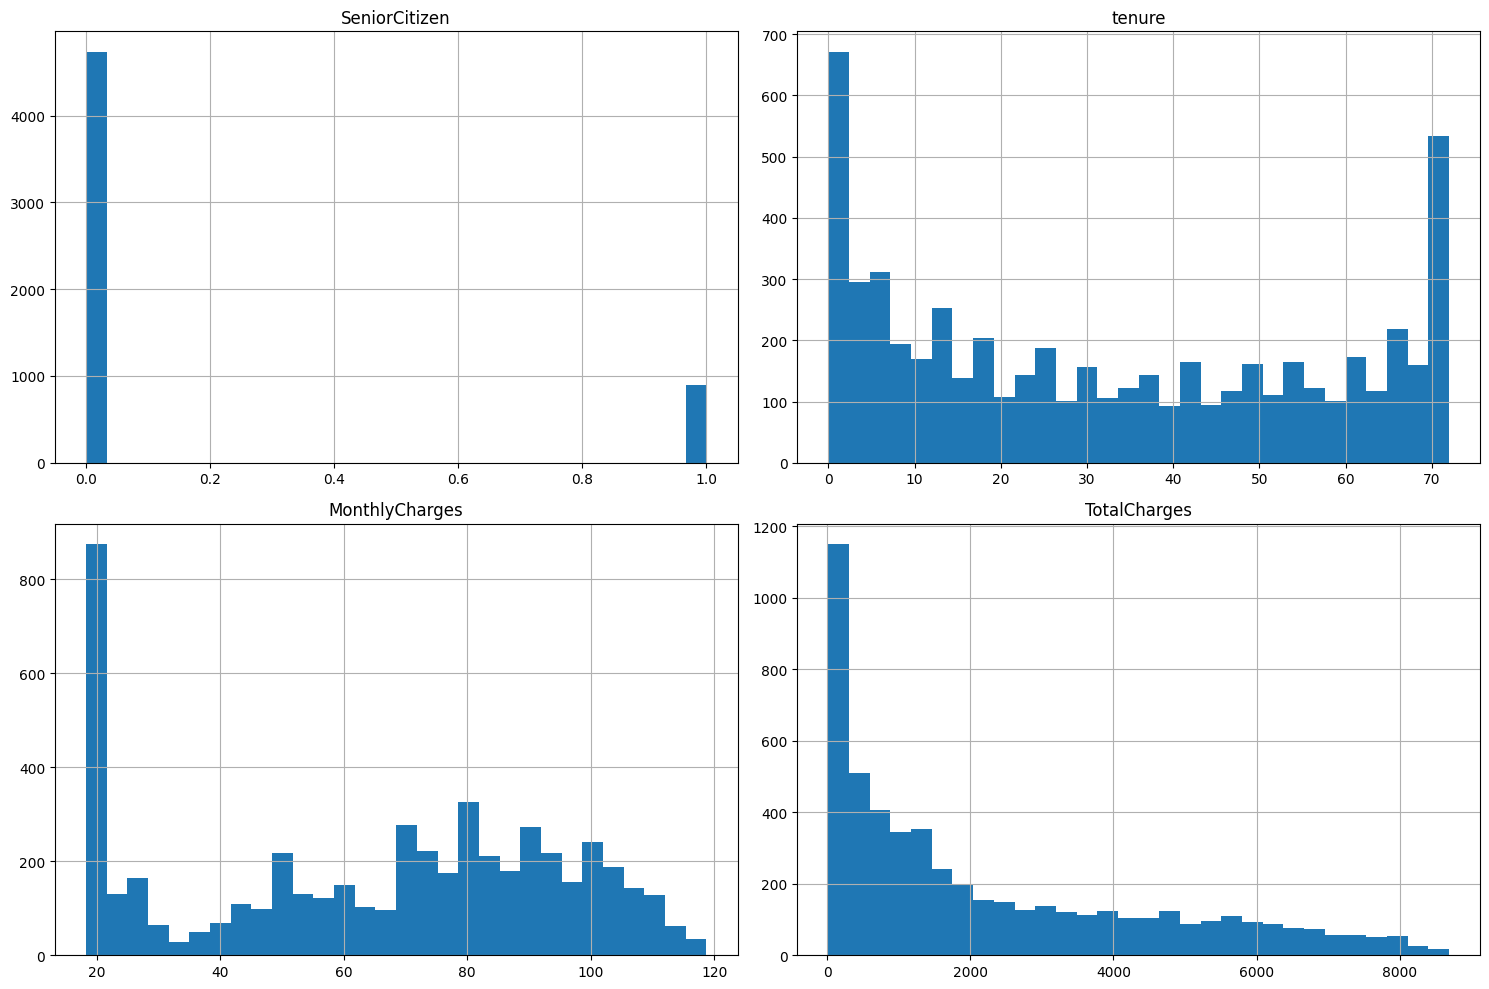

In [24]:
train_df[numerical_cols].hist(
    figsize=(15,10),
    bins=30
)

plt.tight_layout()
plt.show()

## Boxplots for Outlier Detection

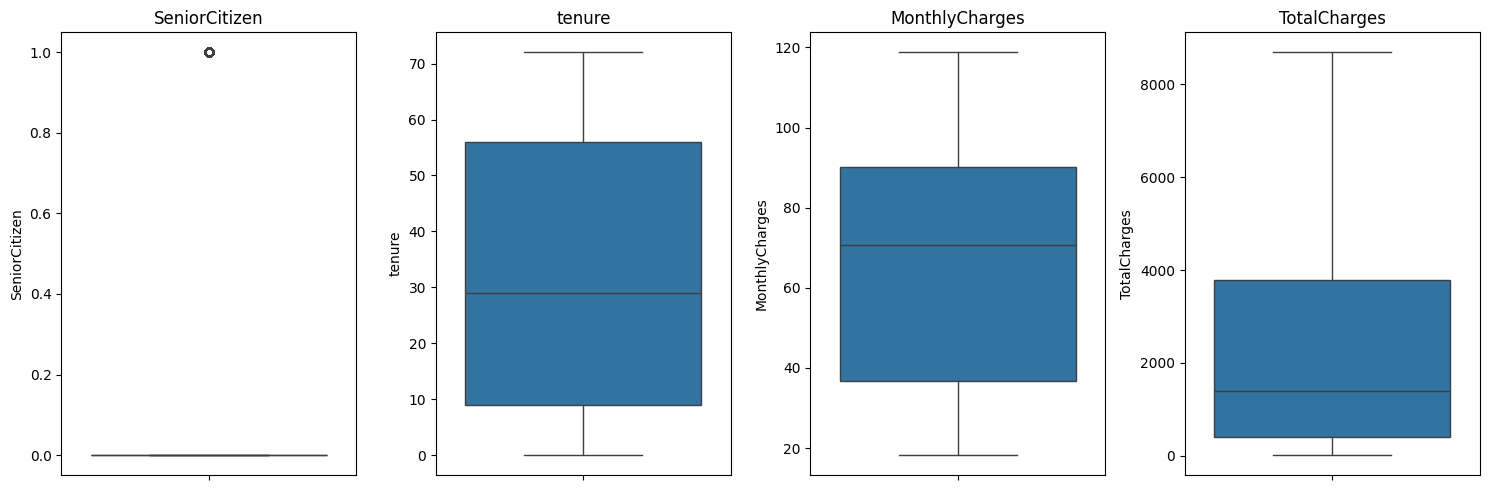

In [25]:
plt.figure(figsize=(15,5))

for i, col in enumerate(numerical_cols, 1):

  plt.subplot(1, len(numerical_cols), i)

  sns.boxplot(
      y=train_df[col]
  )

  plt.title(col)

plt.tight_layout()
plt.show()

## Categorical Feature Analysis

In [26]:
# Countplots for Categorical Features
important_cat_cols = [
    'Contract',
    'PaymentMethod',
    'gender',
    'PaperlessBilling'
]

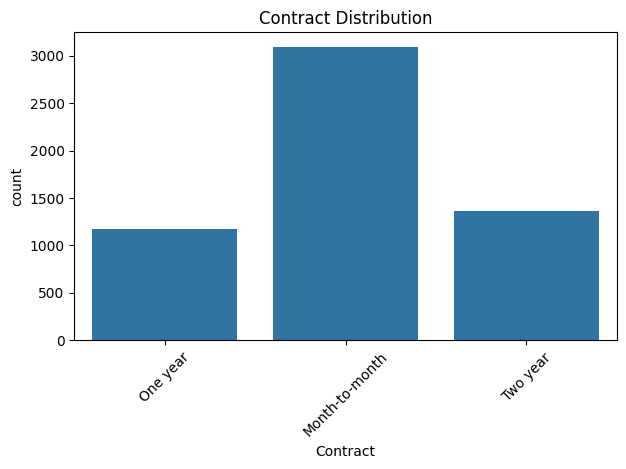

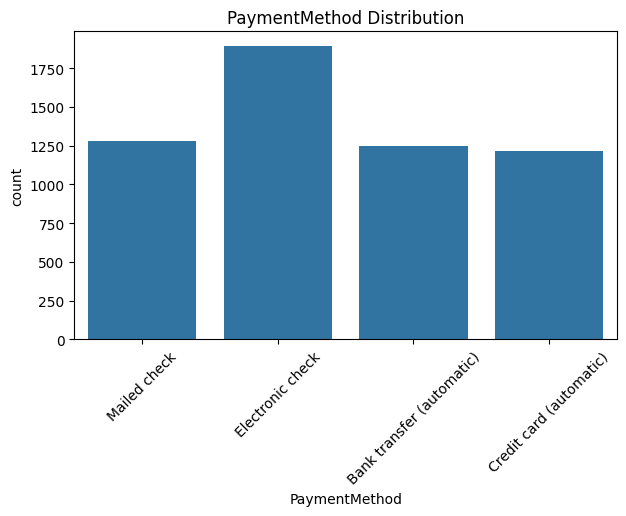

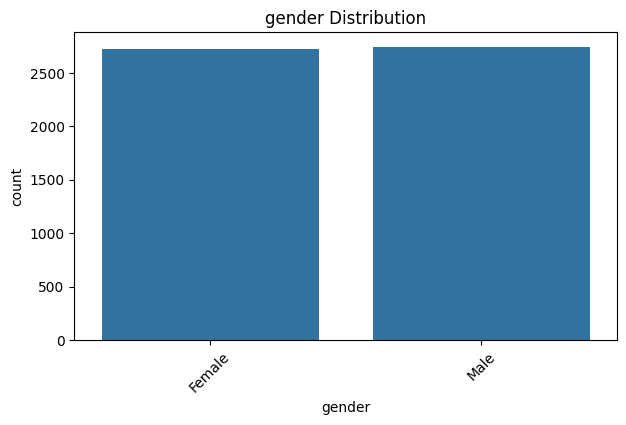

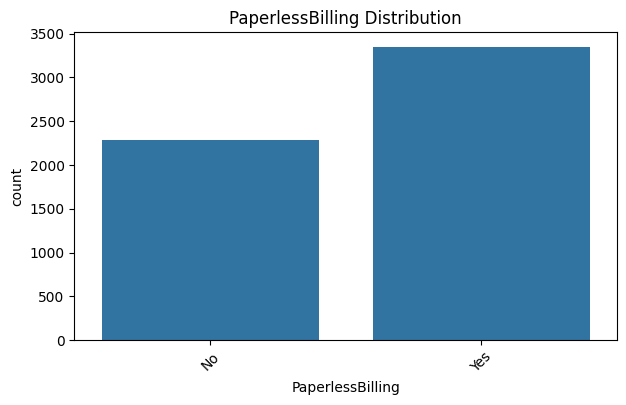

In [27]:
for col in important_cat_cols:

  plt.figure(figsize=(7,4))

  sns.countplot(
      x=col,
      data=train_df
  )

  plt.xticks(rotation=45)

  plt.title(f"{col} Distribution")

  plt.show()

## Relationship Between Features and Churn

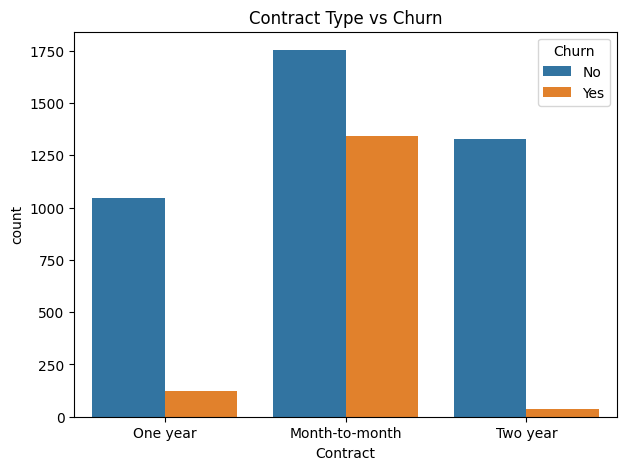

In [28]:
# Churn vs Contract
plt.figure(figsize=(7,5))

sns.countplot(
    x='Contract',
    hue='Churn',
    data=train_df
)

plt.title("Contract Type vs Churn")

plt.show()

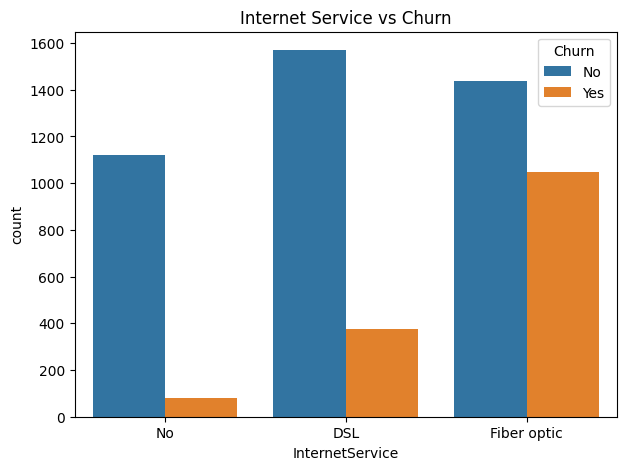

In [29]:
# Churn vs Internet Service
plt.figure(figsize=(7,5))

sns.countplot(
    x='InternetService',
    hue='Churn',
    data=train_df
)

plt.title("Internet Service vs Churn")

plt.show()

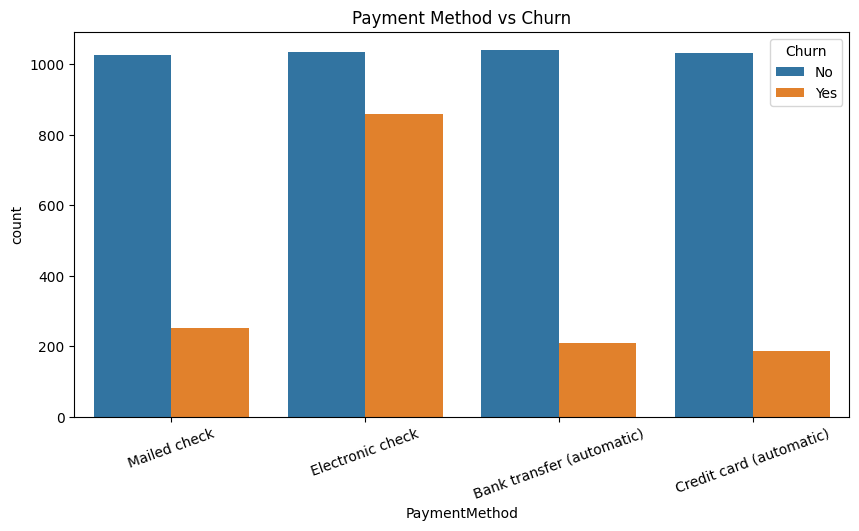

In [30]:
# Churn vs Payment Method
plt.figure(figsize=(10,5))

sns.countplot(
    x='PaymentMethod',
    hue='Churn',
    data=train_df
)

plt.xticks(rotation=20)

plt.title("Payment Method vs Churn")

plt.show()

## Numerical Features vs Churn

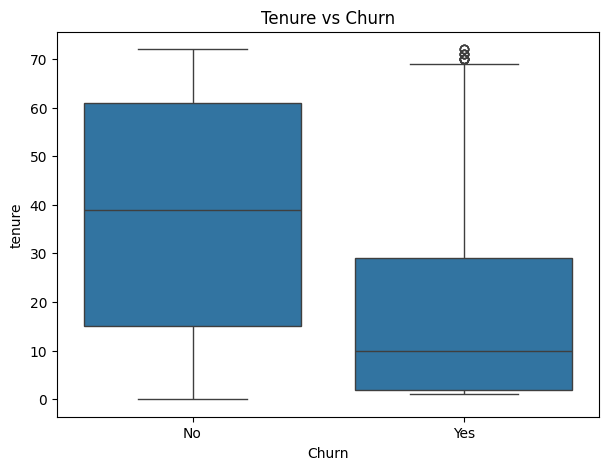

In [31]:
# Tenure vs Churn
plt.figure(figsize=(7,5))

sns.boxplot(
    x='Churn',
    y='tenure',
    data=train_df
)

plt.title("Tenure vs Churn")

plt.show()

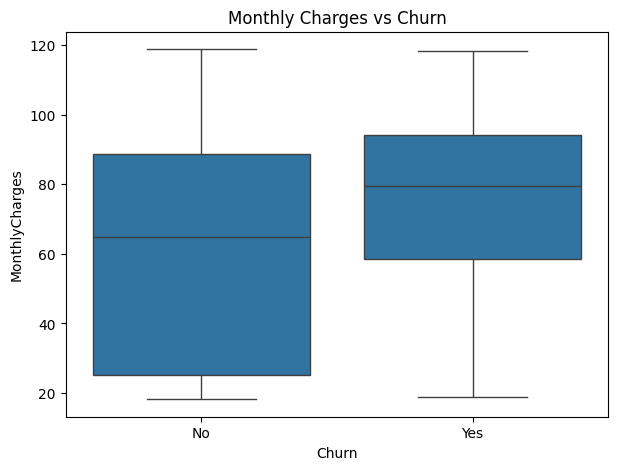

In [32]:
# Monthly Charges vs Churn
plt.figure(figsize=(7,5))

sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=train_df
)

plt.title("Monthly Charges vs Churn")

plt.show()

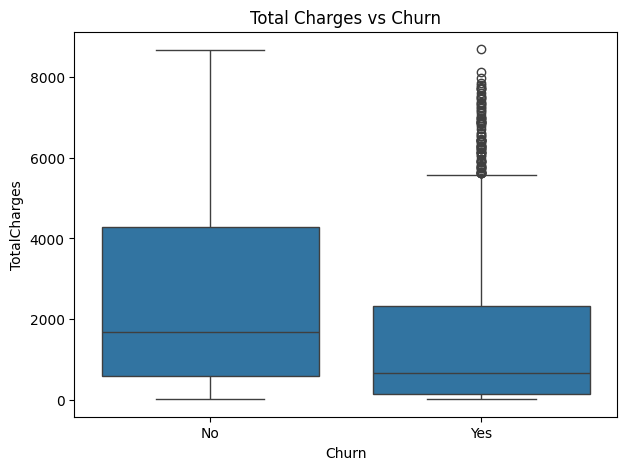

In [33]:
# Total Charges vs Churn
plt.figure(figsize=(7,5))

sns.boxplot(
    x='Churn',
    y='TotalCharges',
    data=train_df
)

plt.title("Total Charges vs Churn")

plt.show()

## Correlation Analysis

In [34]:
# encode churn temporarily
train_df['Churn_numeric'] = train_df['Churn'].map({
    'Yes':1,
    'No':0
})

In [35]:
# Correlation Matrix
correlation_matrix = train_df.corr(
    numeric_only=True
)

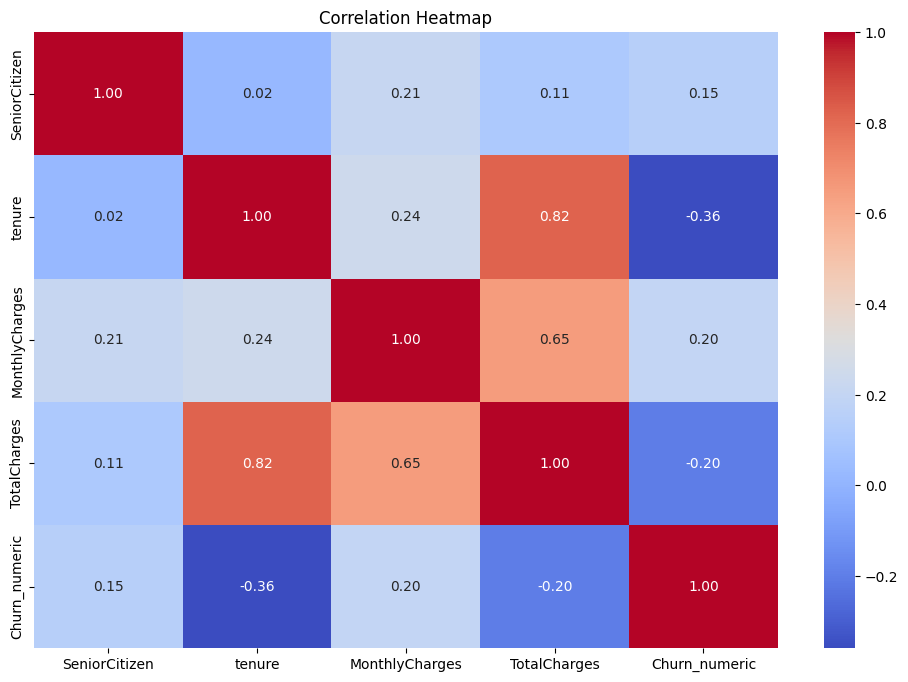

In [36]:
# Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

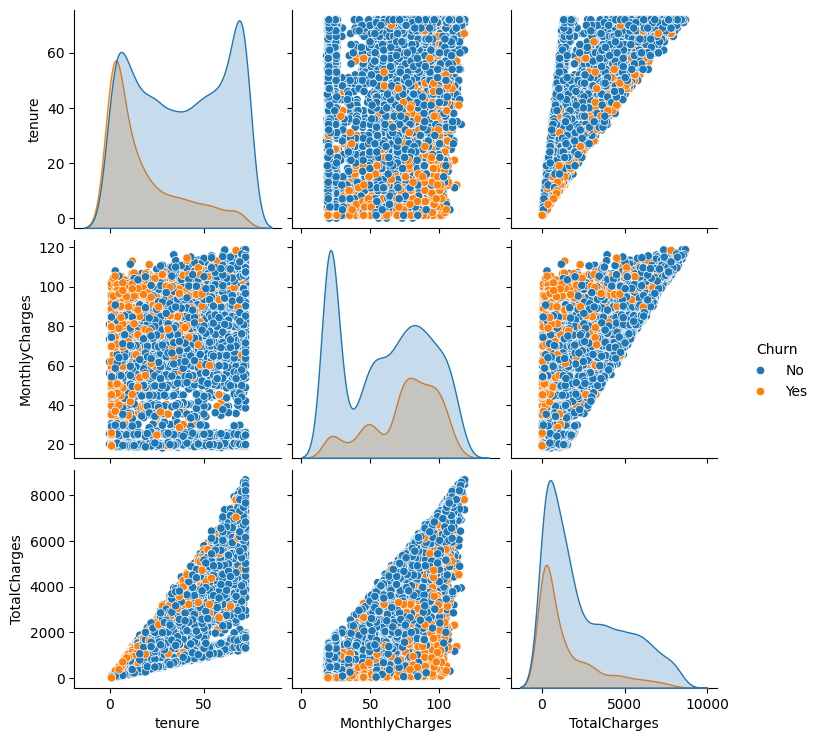

In [37]:
# Pairplot
sns.pairplot(
    train_df[
        [
            'tenure',
            'MonthlyCharges',
            'TotalCharges',
            'Churn'
        ]
    ],
    hue='Churn'
)

plt.show()

In [38]:
train_df.drop('Churn_numeric', axis=1, inplace=True)

# Step 3: Data Preprocessing

This section includes:

- Handling missing values
- Removing duplicates
- Encoding categorical variables
- Handling outliers
- Feature scaling
- Train-test splitting

## Create a Copy of Dataset

In [39]:
train_processed = train_df.copy()
test_processed = test_df.copy()

## Remove Unnecessary Columns

In [40]:
train_processed.drop('customerID', axis=1, inplace=True)
test_processed.drop('customerID', axis=1, inplace=True)

## Handle Missing Values

In [41]:
train_processed.isnull().sum()

,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169
OnlineBackup,0


In [42]:
test_processed.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [43]:
# Handle Data Types
train_processed['TotalCharges'] = pd.to_numeric(train_processed['TotalCharges'], errors='coerce')
test_processed['TotalCharges'] = pd.to_numeric(test_processed['TotalCharges'], errors='coerce')

In [44]:
# Numerical columns
monthlycharges_median = train_processed['MonthlyCharges'].median()

totalcharges_median = train_processed['TotalCharges'].median()

# Categorical Columns
gender_mode = train_processed['gender'].mode()[0]

onlinesecurity_mode = train_processed['OnlineSecurity'].mode()[0]

In [45]:
from functools import total_ordering
# Fill Numerical Missing Values
train_processed['MonthlyCharges'] = train_processed['MonthlyCharges'].fillna(monthlycharges_median)

test_processed['MonthlyCharges'] = test_processed['MonthlyCharges'].fillna(monthlycharges_median)

train_processed['TotalCharges'] = train_processed['TotalCharges'].fillna(totalcharges_median)

test_processed['TotalCharges'] = test_processed['TotalCharges'].fillna(totalcharges_median)

In [46]:
# Fill Categorical Missing Values
train_processed['gender'] = train_processed['gender'].fillna(gender_mode)

test_processed['gender'] = test_processed['gender'].fillna(gender_mode)

train_processed['OnlineSecurity'] = train_processed['OnlineSecurity'].fillna(onlinesecurity_mode)

test_processed['OnlineSecurity'] = test_processed['OnlineSecurity'].fillna(onlinesecurity_mode)

In [47]:
# Verify Missing Values
train_processed.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [48]:
test_processed.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


## Encode Target Variable

In [49]:
# Encode Churn
train_processed['Churn'] = train_processed['Churn'].map({
    'Yes': 1,
    'No': 0
})

test_processed['Churn'] = test_processed['Churn'].map({
    'Yes': 1,
    'No': 0
})

In [50]:
# Verify
train_processed['Churn'].head()

,Churn
0,0
1,0
2,0
3,0
4,0


In [51]:
test_processed['Churn'].head()

,Churn
0,0
1,0
2,1
3,0
4,0


## Identify Categorical Columns

In [52]:
categorical_cols = train_processed.select_dtypes(
    include=['object']
).columns

numerical_cols = train_processed.select_dtypes(
    exclude=['object']
).columns

In [53]:
# View Columns
print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

Categorical Columns:
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

Numerical Columns:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn'], dtype='object')


## Encode Categorical Variables

In [54]:
# Combined train and test for encoding consistency
combined_df = pd.concat(
    [train_processed, test_processed],
    axis=0
)

In [55]:
# One-Hot Encoding
combined_encoded = pd.get_dummies(
    combined_df,
    columns=categorical_cols,
    drop_first=True
)

In [56]:
train_encoded = combined_encoded.iloc[:len(train_processed)]
test_encoded = combined_encoded.iloc[len(train_processed):]

In [57]:
# Reset Index
train_encoded.reset_index(drop=True, inplace=True)
test_encoded.reset_index(drop=True, inplace=True)

In [58]:
print("Original Shape:", train_processed.shape)
print("Encoded Shape:", train_encoded.shape)

Original Shape: (5634, 20)
Encoded Shape: (5634, 31)


In [59]:
print("Original Shape:", test_processed.shape)
print("Encoded Shape:", test_encoded.shape)

Original Shape: (1409, 20)
Encoded Shape: (1409, 31)


In [60]:
# Check Encoded Dataset
train_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,35,20.75,700.45,0,False,False,False,True,False,...,True,False,True,False,True,False,False,False,False,True
1,0,28,35.75,961.40,0,False,False,False,False,True,...,False,False,False,False,False,False,True,False,False,True
2,0,56,98.60,5581.05,0,True,False,False,True,False,...,False,True,False,True,False,False,False,False,True,False
3,0,39,20.45,790.00,0,True,True,False,True,False,...,True,False,True,False,False,True,True,False,False,False
4,0,43,51.25,2151.60,0,False,True,True,False,True,...,False,True,False,False,True,False,True,False,False,False


In [61]:
test_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,40,81.20,3292.30,0,True,True,True,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,12,78.85,876.75,0,False,True,False,True,False,...,False,True,False,True,True,False,False,False,True,False
2,0,43,100.00,4211.55,1,True,False,False,True,False,...,False,True,False,True,True,False,True,False,True,False
3,0,72,118.20,8547.15,0,True,False,False,True,False,...,False,True,False,True,False,True,True,False,True,False
4,0,10,36.25,374.00,0,False,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False


In [62]:
# Compare Shapes
print("Original Shape:", train_processed.shape)
print("Encoded Shape:", train_encoded.shape)

Original Shape: (5634, 20)
Encoded Shape: (5634, 31)


In [63]:
# Compare Shapes
print("Original Shape:", test_processed.shape)
print("Encoded Shape:", test_encoded.shape)

Original Shape: (1409, 20)
Encoded Shape: (1409, 31)


## Separate Features and Target

In [64]:
# features and target
X = train_encoded.drop('Churn', axis=1)
y = train_encoded['Churn']

# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# verify
print(X_train.shape)
print(X_test.shape)

(4507, 30)
(1127, 30)


In [65]:
# Verify Split
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(4507, 30)
(1127, 30)
(4507,)
(1127,)


## Outlier Handling

Outliers were handled using the IQR method to reduce the impact
of extreme values on model performance.

In [66]:
# Outlier Handling using IQR Method

# Select numerical columns only
outlier_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

# Apply IQR method on TRAINING DATA ONLY
for col in outlier_cols:

    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap outliers in training data
    X_train[col] = np.where(
        X_train[col] < lower_bound,
        lower_bound,
        X_train[col]
    )

    X_train[col] = np.where(
        X_train[col] > upper_bound,
        upper_bound,
        X_train[col]
    )

    # Apply SAME bounds to test data
    X_test[col] = np.where(
        X_test[col] < lower_bound,
        lower_bound,
        X_test[col]
    )

    X_test[col] = np.where(
        X_test[col] > upper_bound,
        upper_bound,
        X_test[col]
    )

print("Outlier handling completed.")

Outlier handling completed.


# Step 4: Feature Engineering

New features were created to improve model performance and capture
customer behavior patterns.

In [67]:
# Create a Working Copy
X_train_fe = X_train.copy()

X_test_fe = X_test.copy()

In [68]:
# Customer Lifetime Value Feature
X_train_fe['CLV'] = (
    X_train_fe['tenure'] *
    X_train_fe['MonthlyCharges']
)

X_test_fe['CLV'] = (
    X_test_fe['tenure'] *
    X_test_fe['MonthlyCharges']
)

In [69]:
# Average Monthly Spend Feature
X_train_fe['AverageSpend'] = (
    X_train_fe['TotalCharges'] /
    (X_train_fe['tenure'] + 1)
)

X_test_fe['AverageSpend'] = (
    X_test_fe['TotalCharges'] /
    (X_test_fe['tenure'] + 1)
)

## Service Count Feature

In [70]:
# Identify Service Columns
service_cols = [
    col for col in X_train_fe.columns
    if (
        col.endswith('_Yes')
        and (
            'OnlineSecurity' in col or
            'OnlineBackup' in col or
            'DeviceProtection' in col or
            'TechSupport' in col or
            'StreamingTV' in col or
            'StreamingMovies' in col or
            'PhoneService' in col or
            'MultipleLines' in col
        )
    )
]

print(service_cols)

['PhoneService_Yes', 'MultipleLines_Yes', 'OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes', 'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes']


In [71]:
# Total Active Services

X_train_fe['TotalServices'] = (
    X_train_fe[service_cols]
    .sum(axis=1)
)

X_test_fe['TotalServices'] = (
    X_test_fe[service_cols]
    .sum(axis=1)
)

## Contract Risk Feature

In [72]:
X_train_fe['IsMonthlyContract'] = (
    (
        X_train_fe['Contract_One year'] == 0
    ) &
    (
        X_train_fe['Contract_Two year'] == 0
    )
).astype(int)

X_test_fe['IsMonthlyContract'] = (
    (
        X_test_fe['Contract_One year'] == 0
    ) &
    (
        X_test_fe['Contract_Two year'] == 0
    )
).astype(int)

## Tenure Group Feature

In [73]:
bins = [0, 12, 24, 48, np.inf]

labels = [0, 1, 2, 3]

In [74]:
# Create Tenure Categories
X_train_fe['TenureGroup'] = pd.cut(
    X_train_fe['tenure'],
    bins=bins,
    labels=labels,
    include_lowest=True
).astype(int)

X_test_fe['TenureGroup'] = pd.cut(
    X_test_fe['tenure'],
    bins=bins,
    labels=labels,
    include_lowest=True
).astype(int)

## High Charges Indicator

In [75]:
# premium/high-cost customer indicator
# create feature
monthly_charge_threshold = (
    X_train_fe['MonthlyCharges']
    .median()
)

X_train_fe['HighMonthlyCharges'] = (
    X_train_fe['MonthlyCharges']
    > monthly_charge_threshold
).astype(int)

X_test_fe['HighMonthlyCharges'] = (
    X_test_fe['MonthlyCharges']
    > monthly_charge_threshold
).astype(int)

## Senior Citizen + High Charges Interaction

In [76]:
# Create Feature
X_train_fe['SeniorHighCharges'] = (
    X_train_fe['SeniorCitizen'] *
    X_train_fe['HighMonthlyCharges']
)

X_test_fe['SeniorHighCharges'] = (
    X_test_fe['SeniorCitizen'] *
    X_test_fe['HighMonthlyCharges']
)

## Check New Feature Shapes

In [77]:
print(X_train.shape)

print(X_train_fe.shape)

(4507, 30)
(4507, 37)


## Feature Importance Using Random Forest

In [78]:
# Train Temporary Model
rf_temp = RandomForestClassifier(
    random_state=42
)

rf_temp.fit(
    X_train_fe,
    y_train
)

RandomForestClassifier(random_state=42)

In [79]:
# Extract Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X_train_fe.columns,
    'Importance': rf_temp.feature_importances_
})

In [80]:
# Sort Importance
feature_importance = (
    feature_importance
    .sort_values(
        by='Importance',
        ascending=False
    )
)

In [81]:
# View Top Features
feature_importance.head(15)

,Feature,Importance
30,CLV,0.108102
2,MonthlyCharges,0.105686
3,TotalCharges,0.105436
31,AverageSpend,0.102400
1,tenure,0.099992
33,IsMonthlyContract,0.072732
10,InternetService_Fiber optic,0.036638
34,TenureGroup,0.035425
32,TotalServices,0.030621
28,PaymentMethod_Electronic check,0.028624


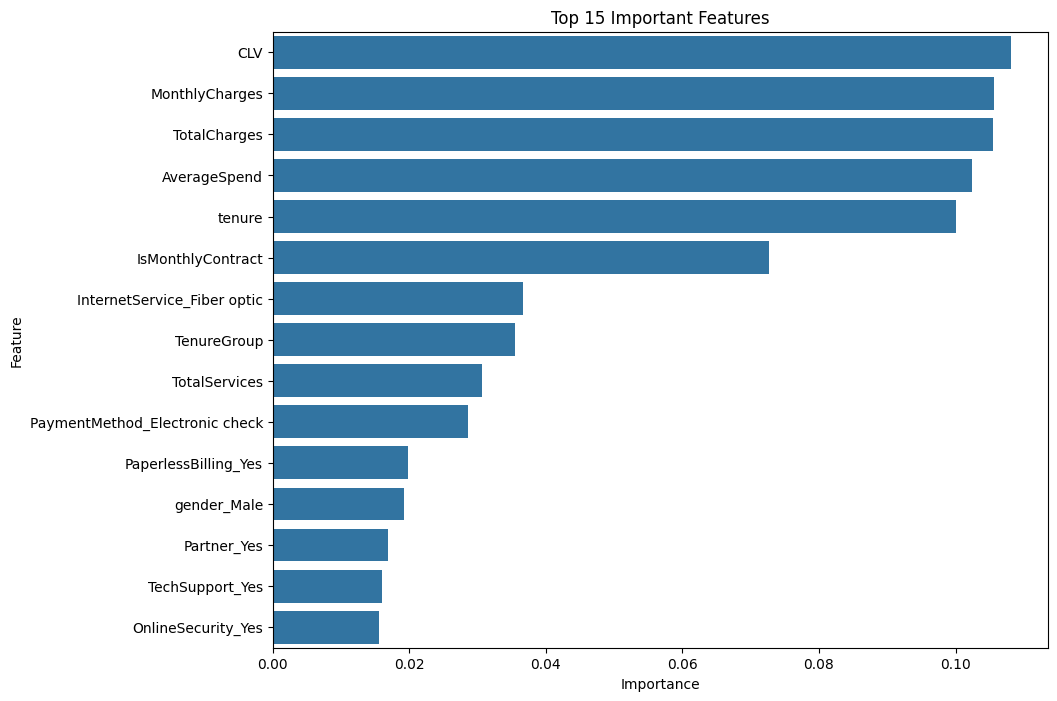

In [82]:
# Visualize Feature Importance
plt.figure(figsize=(10,8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(15)
)

plt.title("Top 15 Important Features")

plt.show()

## Remove Low-Importance Features

In [83]:
# Sometimes:

# irrelevant features add noise
# increase overfitting

# You can remove low-importance columns.

# But for now:

# keep all features

# because tree models handle irrelevant features reasonably well.

## Correlation Between New Features

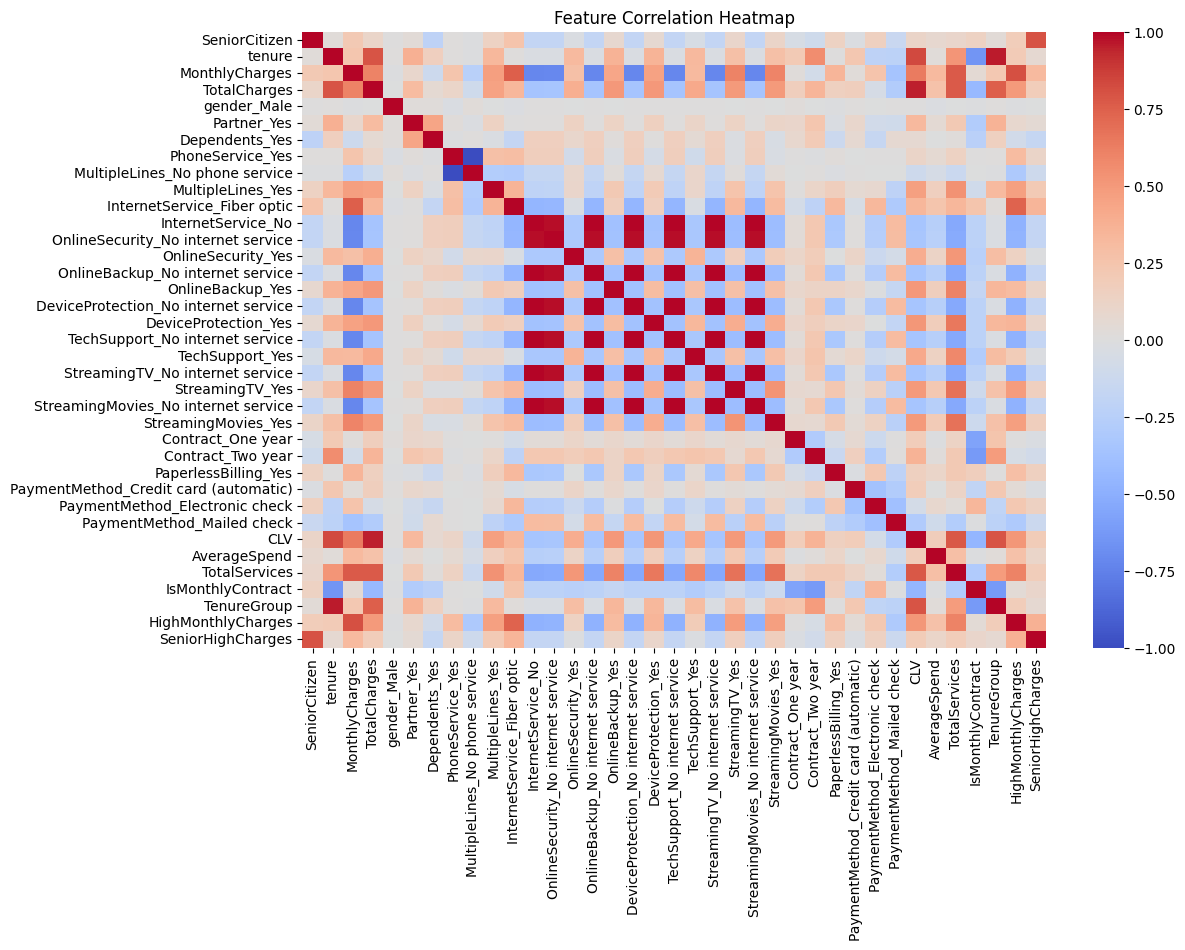

In [84]:
plt.figure(figsize=(12,8))

sns.heatmap(
    X_train_fe.corr(),
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [85]:
print(X_train_fe.shape)
print(X_test_fe.shape)

(4507, 37)
(1127, 37)


In [86]:
# Feature Scaling After Feature Engineering

# initialize scaler
scaler = StandardScaler()

# fit only on training data
X_train_fe_scaled = scaler.fit_transform(X_train_fe)

# transform test data
X_test_fe_scaled = scaler.transform(X_test_fe)

# convert back to dataframe
X_train_fe_scaled = pd.DataFrame(
    X_train_fe_scaled,
    columns=X_train_fe.columns,
    index=X_train_fe.index
)

X_test_fe_scaled = pd.DataFrame(
    X_test_fe_scaled,
    columns=X_test_fe.columns,
    index=X_test_fe.index
)

# verify shapes
print("Train Shape:", X_train_fe_scaled.shape)
print("Test Shape:", X_test_fe_scaled.shape)

Train Shape: (4507, 37)
Test Shape: (1127, 37)


# Step 5: Model Development (Model Building and Model Evaluation)

Multiple machine learning models were trained and evaluated:

- Logistic Regression
- K-Nearest Neighbors (KNN)
- Naive Bayes
- Support Vector Machine (SVM)
- Decision Tree

Different models were evaluated to identify the most suitable
algorithm for customer churn prediction.

Models were evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC Score
- Confusion Matrix

In [87]:
# Create Evaluation Function
def evaluate_model(model, X_train, X_test, y_train, y_test):

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Probability predictions
    try:
        y_prob = model.predict_proba(X_test)[:,1]
    except:
        y_prob = None

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    # Print results
    print("Accuracy:", accuracy)

    print("Precision:", precision)

    print("Recall:", recall)

    print("F1 Score:", f1)

    # ROC-AUC
    if y_prob is not None:

        auc = roc_auc_score(y_test, y_prob)

        print("ROC-AUC:", auc)

    # Confusion Matrix
    print("\nConfusion Matrix")

    print(confusion_matrix(y_test, y_pred))

    # Classification Report
    print("\nClassification Report")

    print(classification_report(y_test, y_pred))

    return {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1': f1
    }

## Logistic Regression

In [88]:
# Initialize Model
log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'  # to handle imbalanced data
)

In [89]:
# Evaluate
log_results = evaluate_model(
    log_model,
    X_train_fe_scaled,
    X_test_fe_scaled,
    y_train,
    y_test
)

Accuracy: 0.7506654835847383
Precision: 0.5218340611353712
Recall: 0.7940199335548173
F1 Score: 0.6297760210803689
ROC-AUC: 0.8464118796907807

Confusion Matrix
[[607 219]
 [ 62 239]]

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.73      0.81       826
           1       0.52      0.79      0.63       301

    accuracy                           0.75      1127
   macro avg       0.71      0.76      0.72      1127
weighted avg       0.80      0.75      0.76      1127



## K-Nearest Neighbors (KNN)

In [90]:
# Initialize Model
knn_model = KNeighborsClassifier(
    n_neighbors=5,
)

In [91]:
# Evaluate
knn_results = evaluate_model(
    knn_model,
    X_train_fe_scaled,
    X_test_fe_scaled,
    y_train,
    y_test
)

Accuracy: 0.7728482697426797
Precision: 0.5737704918032787
Recall: 0.5813953488372093
F1 Score: 0.5775577557755776
ROC-AUC: 0.7880873279544376

Confusion Matrix
[[696 130]
 [126 175]]

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.84      0.84       826
           1       0.57      0.58      0.58       301

    accuracy                           0.77      1127
   macro avg       0.71      0.71      0.71      1127
weighted avg       0.77      0.77      0.77      1127



## Naive Bayes

In [92]:
# Initialize Model
nb_model = GaussianNB()

In [93]:
# Evaluate
nb_results = evaluate_model(
    nb_model,
    X_train_fe_scaled,
    X_test_fe_scaled,
    y_train,
    y_test
)

Accuracy: 0.7080745341614907
Precision: 0.4734848484848485
Recall: 0.8305647840531561
F1 Score: 0.6031363088057901
ROC-AUC: 0.8298649376975858

Confusion Matrix
[[548 278]
 [ 51 250]]

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.66      0.77       826
           1       0.47      0.83      0.60       301

    accuracy                           0.71      1127
   macro avg       0.69      0.75      0.69      1127
weighted avg       0.80      0.71      0.72      1127



## Support Vector Machine (SVM)

In [94]:
# Initialize Model
svm_model = SVC(
    probability=True,
    class_weight='balanced'
)

In [95]:
# Evaluate
svm_results = evaluate_model(
    svm_model,
    X_train_fe_scaled,
    X_test_fe_scaled,
    y_train,
    y_test
)

Accuracy: 0.7506654835847383
Precision: 0.5218340611353712
Recall: 0.7940199335548173
F1 Score: 0.6297760210803689
ROC-AUC: 0.827532116512352

Confusion Matrix
[[607 219]
 [ 62 239]]

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.73      0.81       826
           1       0.52      0.79      0.63       301

    accuracy                           0.75      1127
   macro avg       0.71      0.76      0.72      1127
weighted avg       0.80      0.75      0.76      1127



## Decision Tree

In [96]:
# Initialize Model
dt_model = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced'
)

In [97]:
# Evaluate
dt_results = evaluate_model(
    dt_model,
    X_train_fe,
    X_test_fe,
    y_train,
    y_test
)

Accuracy: 0.735581188997338
Precision: 0.5052631578947369
Recall: 0.47840531561461797
F1 Score: 0.49146757679180886
ROC-AUC: 0.6538636345354066

Confusion Matrix
[[685 141]
 [157 144]]

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.83      0.82       826
           1       0.51      0.48      0.49       301

    accuracy                           0.74      1127
   macro avg       0.66      0.65      0.66      1127
weighted avg       0.73      0.74      0.73      1127



## Compare Models

In [98]:
# Create Results DataFrame
results_df = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'KNN',
        'Naive Bayes',
        'SVM',
        'Decision Tree'
    ],

    'Accuracy': [
        log_results['Accuracy'],
        knn_results['Accuracy'],
        nb_results['Accuracy'],
        svm_results['Accuracy'],
        dt_results['Accuracy']
    ],

    'Precision': [
        log_results['Precision'],
        knn_results['Precision'],
        nb_results['Precision'],
        svm_results['Precision'],
        dt_results['Precision']
    ],

    'Recall': [
        log_results['Recall'],
        knn_results['Recall'],
        nb_results['Recall'],
        svm_results['Recall'],
        dt_results['Recall']
    ],

    'F1 Score': [
        log_results['F1'],
        knn_results['F1'],
        nb_results['F1'],
        svm_results['F1'],
        dt_results['F1']
    ]
})

In [99]:
# Display Results
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.750665,0.521834,0.794020,0.629776
1,KNN,0.772848,0.573770,0.581395,0.577558
2,Naive Bayes,0.708075,0.473485,0.830565,0.603136
3,SVM,0.750665,0.521834,0.794020,0.629776
4,Decision Tree,0.735581,0.505263,0.478405,0.491468


In [100]:
# Sort Best Models
results_df.sort_values(
    by='F1 Score',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.750665,0.521834,0.794020,0.629776
3,SVM,0.750665,0.521834,0.794020,0.629776
2,Naive Bayes,0.708075,0.473485,0.830565,0.603136
1,KNN,0.772848,0.573770,0.581395,0.577558
4,Decision Tree,0.735581,0.505263,0.478405,0.491468


## Visualize Model Performance

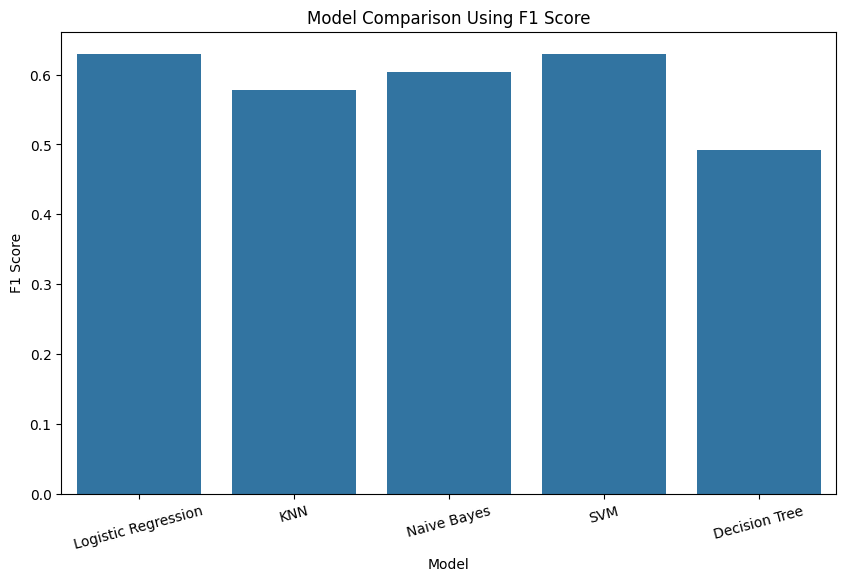

In [101]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Model',
    y='F1 Score',
    data=results_df
)

plt.xticks(rotation=15)

plt.title("Model Comparison Using F1 Score")

plt.show()

# Step 6: Hyperparameter Tuning

GridSearchCV was used to optimize model parameters and improve
overall performance.

## Hyperparameter Tuning for KNN

In [102]:
# Create Parameter Grid
knn_params = {
    'n_neighbors': [3,5,7,9,11,13],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

In [103]:
# Create GridSearchCV
knn_grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=knn_params,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

In [104]:
knn_grid.fit(
    X_train_fe_scaled,
    y_train
)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [3, 5, 7, 9, 11, 13],
                         'weights': ['uniform', 'distance']},
             scoring='f1')

In [105]:
# Best Parameters
print(knn_grid.best_params_)

{'metric': 'euclidean', 'n_neighbors': 13, 'weights': 'uniform'}


In [106]:
# Best Score
print(knn_grid.best_score_)

0.5845249452167385


In [107]:
# Best KNN Model
best_knn = knn_grid.best_estimator_

In [108]:
knn_tuned_results = evaluate_model(
    best_knn,
    X_train_fe_scaled,
    X_test_fe_scaled,
    y_train,
    y_test
)

Accuracy: 0.7772848269742679
Precision: 0.5816993464052288
Recall: 0.5913621262458472
F1 Score: 0.586490939044481
ROC-AUC: 0.815103810542743

Confusion Matrix
[[698 128]
 [123 178]]

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       826
           1       0.58      0.59      0.59       301

    accuracy                           0.78      1127
   macro avg       0.72      0.72      0.72      1127
weighted avg       0.78      0.78      0.78      1127



## Hyperparameter Tuning for SVM

In [109]:
# Create Parameter Grid
svm_params = {

    'C': [0.1, 1, 10],

    'kernel': ['linear', 'rbf'],

    'gamma': ['scale', 'auto']
}

In [110]:
# Create GridSearch
svm_grid = GridSearchCV(
    estimator=SVC(probability=True),
    param_grid=svm_params,
    scoring='f1',
    cv=3,
    n_jobs=-1
)

In [111]:
# Train
svm_grid.fit(
    X_train_fe_scaled,
    y_train
)

GridSearchCV(cv=3, estimator=SVC(probability=True), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf']},
             scoring='f1')

In [112]:
# Best Parameters
print(svm_grid.best_params_)

{'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}


In [113]:
# Best SVM Model
best_svm = svm_grid.best_estimator_

In [114]:
# Evaluate Tuned SVM
svm_tuned_results = evaluate_model(
    best_svm,
    X_train_fe_scaled,
    X_test_fe_scaled,
    y_train,
    y_test
)

Accuracy: 0.7959183673469388
Precision: 0.6381322957198443
Recall: 0.5448504983388704
F1 Score: 0.5878136200716846
ROC-AUC: 0.8304018887807391

Confusion Matrix
[[733  93]
 [137 164]]

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.89      0.86       826
           1       0.64      0.54      0.59       301

    accuracy                           0.80      1127
   macro avg       0.74      0.72      0.73      1127
weighted avg       0.79      0.80      0.79      1127



## Hyperparameter Tuning for Decision Tree

In [115]:
# Parameter Grid
dt_params = {

    'max_depth': [3,5,7,10,None],

    'min_samples_split': [2,5,10],

    'min_samples_leaf': [1,2,4],

    'criterion': ['gini', 'entropy']
}

In [116]:
# Create GridSearch
dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(
        random_state=42
    ),
    param_grid=dt_params,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

In [117]:
# Train
dt_grid.fit(
    X_train_fe,
    y_train
)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, 10, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='f1')

In [118]:
# Best Parameters
print(dt_grid.best_params_)

{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}


In [119]:
# Best Model
best_dt = dt_grid.best_estimator_

In [120]:
# Evaluate Tuned Decision Tree
dt_tuned_results = evaluate_model(
    best_dt,
    X_train_fe,
    X_test_fe,
    y_train,
    y_test
)

Accuracy: 0.7985803016858918
Precision: 0.6284722222222222
Recall: 0.6013289036544851
F1 Score: 0.6146010186757216
ROC-AUC: 0.8350836195731741

Confusion Matrix
[[719 107]
 [120 181]]

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.87      0.86       826
           1       0.63      0.60      0.61       301

    accuracy                           0.80      1127
   macro avg       0.74      0.74      0.74      1127
weighted avg       0.80      0.80      0.80      1127



## Logistic Regression Tuning

In [121]:
# Parameter Grid
log_params = {

    'C': [0.01, 0.1, 1, 10],

    'solver': ['liblinear', 'lbfgs']
}

In [122]:
# Create GridSearch
log_grid = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=1000
    ),
    param_grid=log_params,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

In [123]:
# Train
log_grid.fit(
    X_train_fe_scaled,
    y_train
)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10],
                         'solver': ['liblinear', 'lbfgs']},
             scoring='f1')

In [124]:
# Best Parameters
print(log_grid.best_params_)

{'C': 0.01, 'solver': 'liblinear'}


In [125]:
# Best Model
best_log = log_grid.best_estimator_

In [126]:
# Evaluate Tuned Logistic Regression
log_tuned_results = evaluate_model(
    best_log,
    X_train_fe_scaled,
    X_test_fe_scaled,
    y_train,
    y_test
)

Accuracy: 0.8047914818101154
Precision: 0.6483516483516484
Recall: 0.5880398671096345
F1 Score: 0.6167247386759582
ROC-AUC: 0.8420599615486716

Confusion Matrix
[[730  96]
 [124 177]]

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.88      0.87       826
           1       0.65      0.59      0.62       301

    accuracy                           0.80      1127
   macro avg       0.75      0.74      0.74      1127
weighted avg       0.80      0.80      0.80      1127



## Compare Tuned Models

In [127]:
# Create Results DataFrame
tuned_results_df = pd.DataFrame({

    'Model': [
        'Tuned Logistic Regression',
        'Tuned KNN',
        'Tuned SVM',
        'Tuned Decision Tree'
    ],

    'Accuracy': [
        log_tuned_results['Accuracy'],
        knn_tuned_results['Accuracy'],
        svm_tuned_results['Accuracy'],
        dt_tuned_results['Accuracy']
    ],

    'Precision': [
        log_tuned_results['Precision'],
        knn_tuned_results['Precision'],
        svm_tuned_results['Precision'],
        dt_tuned_results['Precision']
    ],

    'Recall': [
        log_tuned_results['Recall'],
        knn_tuned_results['Recall'],
        svm_tuned_results['Recall'],
        dt_tuned_results['Recall']
    ],

    'F1 Score': [
        log_tuned_results['F1'],
        knn_tuned_results['F1'],
        svm_tuned_results['F1'],
        dt_tuned_results['F1']
    ]
})

In [128]:
# View Results
tuned_results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Tuned Logistic Regression,0.804791,0.648352,0.588040,0.616725
1,Tuned KNN,0.777285,0.581699,0.591362,0.586491
2,Tuned SVM,0.795918,0.638132,0.544850,0.587814
3,Tuned Decision Tree,0.798580,0.628472,0.601329,0.614601


In [129]:
# Sort by Best F1 Score
tuned_results_df.sort_values(
    by='F1 Score',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Tuned Logistic Regression,0.804791,0.648352,0.588040,0.616725
3,Tuned Decision Tree,0.798580,0.628472,0.601329,0.614601
2,Tuned SVM,0.795918,0.638132,0.544850,0.587814
1,Tuned KNN,0.777285,0.581699,0.591362,0.586491


## Visualize Tuned Models

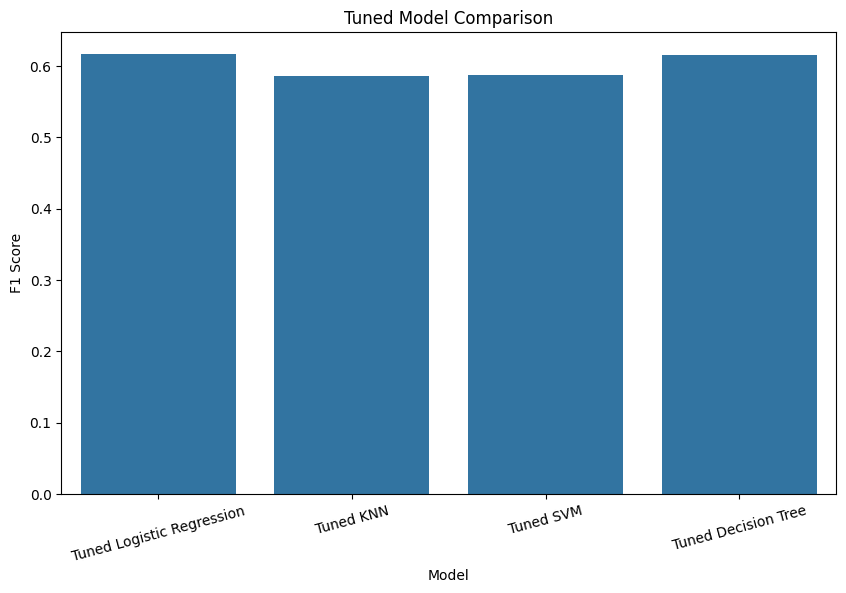

In [130]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Model',
    y='F1 Score',
    data=tuned_results_df
)

plt.xticks(rotation=15)

plt.title("Tuned Model Comparison")

plt.show()

Hyperparameter tuning improved model generalization and helped
identify the best-performing configuration.

# Step 7: Conclusion

## Final Evaluation and Business Conclusion

Business Insights

Key findings from the analysis:

- Customers with month-to-month contracts are more likely to churn.
- Customers with high monthly charges have higher churn probability.
- Customers with low tenure are at greater risk of leaving.
- Fiber optic internet customers showed relatively high churn.
- Long-term contracts improve customer retention.

## Final Conclusion

This project successfully developed a machine learning pipeline for
customer churn prediction.

Among all evaluated models, Tuned Logistic Regression achieved
the best overall performance based on F1 Score and Accuracy.

The analysis revealed that contract type, tenure, monthly charges,
and customer service usage are major churn indicators.

The final model can help businesses:

- Predict customer churn early
- Improve customer retention
- Reduce revenue loss
- Design targeted retention campaigns